In [1]:
# importando modulos necesarios
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import sympy 
from scipy import integrate

# imprimir con notación matemática.
sympy.init_printing(use_latex='mathjax')

In [2]:
Deltarx=-87150 #J/mol

To=433 #K
Ta=433 #K
D=0.1016 #m
a=4/D #1/m
U=8.36*10**5 #J/m2 h K

Cp=525 #J/mol
Cao=3600 #mol/m3
Fao=590 #mol/h
R=8.314 #J/mol K

sumFCp=Fao*Cp #J/molK

def xT_difV(x_T,v): # se define la función con el sistema de ecuaciones dif. y se prueba con un valor arbitrario
    x , T =x_T
    
    k_rx=2.511*(10**14)*np.exp(-121000/(R*T))
    C_a=Cao*(1-x)*To/T
    r_rx=-k_rx*C_a
    
    dxdv= -r_rx/Fao
    dTdv= (r_rx*Deltarx+U*a*(Ta-T))/sumFCp
    return np.array([dxdv,dTdv])

xT_difV([0,To],0)

array([  3.87278184, 642.88178564])

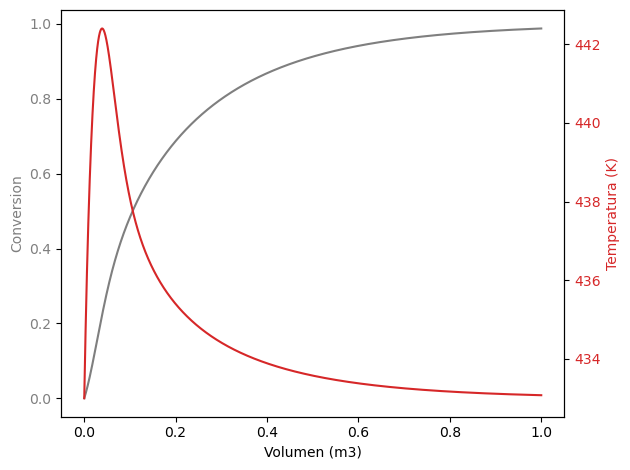

Tmax:442.403K
V:0.7690m3 x:0.96999 T:433.19K
V:0.7691m3 x:0.97001 T:433.19K


In [4]:
ic=[0,To] #solución del sistema de ec. diferencial, se guarda en la matriz "sol"
t = np.linspace(0, 1, 10000)

sol=integrate.odeint(xT_difV,ic,t)
sol

x=sol[:,0] #asignación de los valores de la matriz "sol" en el valor que corresponde, x, y 
T=sol[:,1]

#Graficaremos
data1 = x
data2 = T

fig, ax1 = plt.subplots()

color = 'tab:gray'
ax1.set_xlabel('Volumen (m3)')
ax1.set_ylabel('Conversion', color=color)
ax1.plot(t, data1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Temperatura (K)', color=color)  # we already handled the x-label with ax1
ax2.plot(t, data2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()
 
print(f'Tmax:{np.amax(T):1.3f}K')
for i in range(len(t)):
    if (x[i]>0.96999 and x[i]<0.97001):
        print(f'V:{t[i]:1.4f}m3 x:{x[i]:1.5f} T:{T[i]:1.2f}K')